<a href="https://colab.research.google.com/github/frappedegansito/MachineLearning/blob/main/Unidad%203/ProyectoFinal_U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

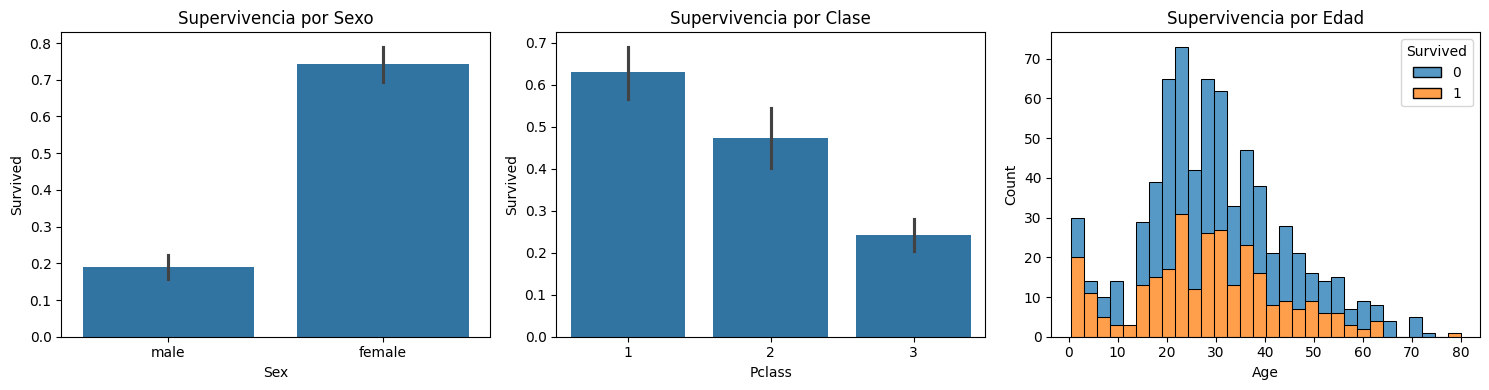

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import kagglehub

df = pd.read_csv('Tinanitc-data-train.csv')

# --- Análisis Exploratorio (EDA) ---
plt.figure(figsize=(15, 4))

# Supervivencia por Sexo
plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Supervivencia por Sexo')

# Supervivencia por Clase
plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Supervivencia por Clase')

# Supervivencia por Edad (Distribución)
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Supervivencia por Edad')

plt.tight_layout()
plt.show()

In [2]:
# --- Limpieza de valores nulos ---
# Edad: Rellenamos con la mediana
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked: Rellenamos con el valor más frecuente (la moda)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabina: Eliminamos la columna por tener demasiados nulos
df = df.drop('Cabin', axis=1)

# --- Selección de variables significativas ---
# Omitimos PassengerId, Name, y Ticket porque no aportan valor predictivo directo
columnas_seleccionadas = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']
df = df[columnas_seleccionadas]

# --- Codificación de variables categóricas ---
# Sex: 0 = masculino, 1 = femenino
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked: Usaremos LabelEncoder
le = LabelEncoder()
df['Embarked'] = le.fit_transform(df['Embarked'])

# --- Definir variable objetivo (X e y) ---
X = df.drop('Survived', axis=1)
y = df['Survived'] # 1 = sobrevivió, 0 = no sobrevivió

# --- División del dataset (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# --- Escalamiento de variables numéricas ---
scaler = StandardScaler()
# Solo ajustamos con train y transformamos tanto train como test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Preparación de datos completada!")
print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

¡Preparación de datos completada!
Tamaño de entrenamiento: (623, 7)
Tamaño de prueba: (268, 7)



Modelo: KNN

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       165
           1       0.74      0.68      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.79      0.79      0.79       268



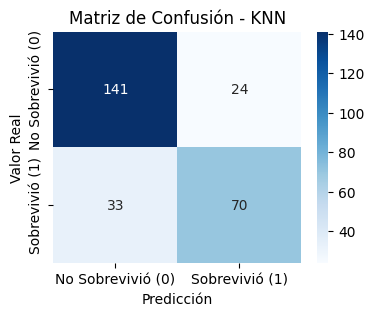


Modelo: Regresión Logística

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       165
           1       0.74      0.71      0.73       103

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



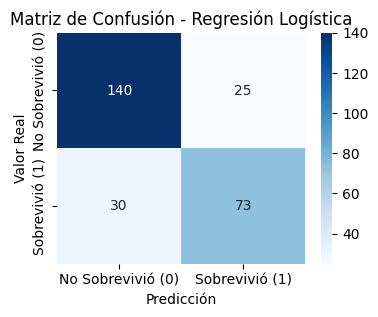


Modelo: Árbol de Decisión

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       165
           1       0.72      0.65      0.68       103

    accuracy                           0.77       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.77      0.77      0.77       268



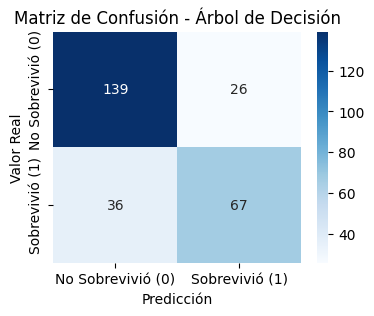


Modelo: Random Forest

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       165
           1       0.76      0.66      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.79      0.79      0.79       268



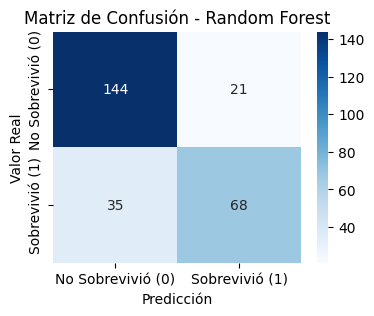


Modelo: SVM

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       165
           1       0.78      0.68      0.73       103

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.80      0.80       268



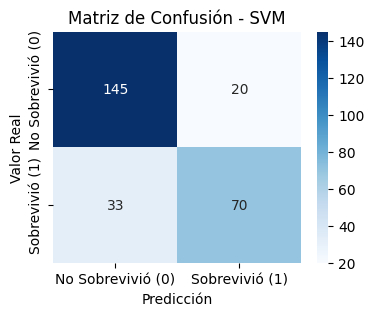

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definir el diccionario con los modelos
modelos = {
    "KNN": KNeighborsClassifier(),
    "Regresión Logística": LogisticRegression(random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

# 2. Entrenar y evaluar cada modelo
for nombre, modelo in modelos.items():
    print(f"\n{'='*60}")
    print(f"Modelo: {nombre}")
    print(f"{'='*60}")

    # Entrenar y predecir
    if nombre in ["Árbol de Decisión", "Random Forest"]:
        # Los árboles no necesitan escalado
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
    else:
        # KNN, SVM y Regresión Logística usan datos escalados
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)

    # 3. Reporte de clasificación
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # 4. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Sobrevivió (0)', 'Sobrevivió (1)'],
                yticklabels=['No Sobrevivió (0)', 'Sobrevivió (1)'])
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

Parte 3. Interpretación individual
1. KNN (K-Nearest Neighbors)
¿Cómo funciona?: Es un algoritmo basado en instancias que clasifica a un nuevo pasajero buscando sus "K" vecinos más cercanos en el espacio de datos.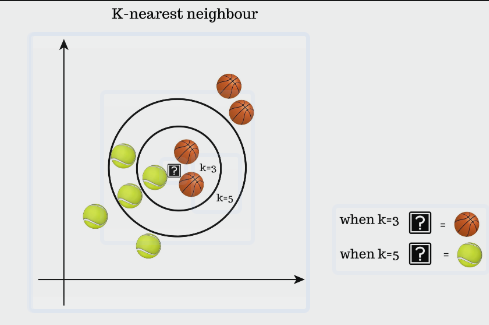

Si la mayoría de sus vecinos sobrevivió, el algoritmo predecirá que ese pasajero también sobrevivió.Ventajas: Es intuitivo, fácil de entender y no asume ninguna distribución subyacente de los datos.Limitaciones: Es muy sensible a variables irrelevantes y al escalamiento (por eso tuvimos que escalar los datos). Además, es computacionalmente costoso si el dataset crece mucho.Interpretación de resultados: * ¿Detecta bien a los sobrevivientes (1)?: Su recall para la clase 1 fue de [Escribe el recall de la clase 1], lo que indica que detecta un [Escribe porcentaje, ej. 65%] de los sobrevivientes reales.¿Detecta bien a los no sobrevivientes (0)?: Su recall para la clase 0 fue de [Escribe el recall de la clase 0].Posibles causas del rendimiento: Al depender de la distancia, puede estar sufriendo por la "maldición de la dimensionalidad" o porque algunas zonas de los datos tienen sobrevivientes y víctimas muy mezclados.Recomendaciones de mejora: Se podría mejorar realizando un Ajuste de hiperparámetros, probando distintos valores para $K$ (el número de vecinos) o usando distintas métricas de distancia (Manhattan o Euclidiana).

2.Regresión Logística

¿Cómo funciona?: Utiliza una función matemática (la función sigmoide) para calcular la probabilidad de que un pasajero pertenezca a una clase (ej. probabilidad de sobrevivir). Si la probabilidad es mayor a 0.5, lo clasifica como "Sobrevivió".

Ventajas: Es un modelo lineal muy rápido, altamente interpretable (nos dice qué peso tiene cada variable) y excelente como modelo base de referencia.

Limitaciones: Asume que existe una relación lineal entre las variables de entrada y el resultado (log-odds). No maneja bien las relaciones complejas o no lineales.

Interpretación de resultados:

¿Detecta bien a los sobrevivientes (1)?: El recall de la clase 1 es de [Escribe el recall de la clase 1].

¿Detecta bien a los no sobrevivientes (0)?: El recall de la clase 0 es de [Escribe el recall de la clase 0].

Posibles causas del rendimiento: Su rendimiento se debe a que el problema del Titanic tiene relaciones lineales fuertes (ej. ser mujer = mayor probabilidad), pero falla en los casos más atípicos.

Recomendaciones de mejora: Feature engineering, como crear nuevas variables (ej. combinar SibSp y Parch en una sola variable llamada TamañoFamilia) para darle más información útil al modelo.

3. Árbol de Decisión
¿Cómo funciona?: Divide el conjunto de datos aplicando reglas lógicas secuenciales basadas en las variables (por ejemplo, ¿Es mujer? -> ¿Tiene menos de 10 años? -> ¿Viaja en 1ra clase?)

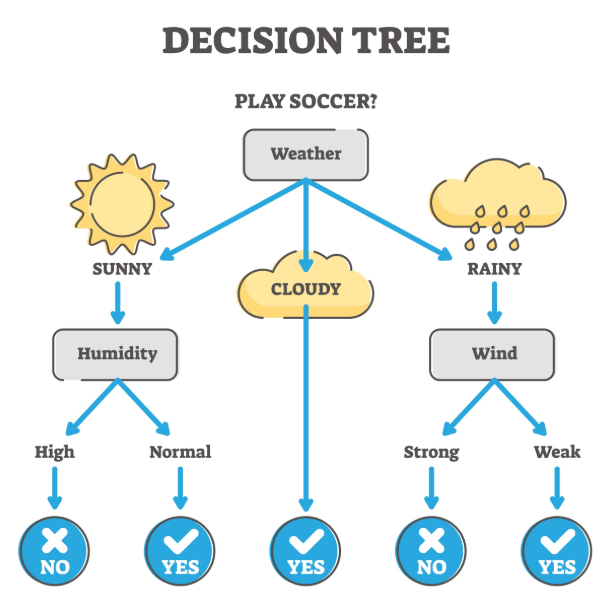

Crea una estructura de árbol hasta llegar a una "hoja" que contiene la predicción final.

Ventajas: No requiere escalamiento de datos, es el más fácil de visualizar e interpretar, y maneja bien las relaciones no lineales.

Limitaciones: Es extremadamente propenso al sobreajuste (overfitting), memorizando los datos de entrenamiento pero fallando en los datos nuevos.

Interpretación de resultados:

¿Detecta bien a los sobrevivientes (1)?: Obtuvo un recall de [Escribe el recall de la clase 1].

¿Detecta bien a los no sobrevivientes (0)?: Obtuvo un recall de [Escribe el recall de la clase 0].

Posibles causas del rendimiento: Si el modelo tiene un rendimiento muy alto en entrenamiento pero bajo en prueba, es debido a que el árbol creció demasiado y se sobreajustó.

Recomendaciones de mejora: Ajuste de hiperparámetros, específicamente limitando la profundidad máxima del árbol (max_depth) o exigiendo un número mínimo de muestras para dividirse (min_samples_split).

4. Random Forest
¿Cómo funciona?: Es un "ensamble" que crea múltiples árboles de decisión independientes utilizando subconjuntos aleatorios de datos y variables

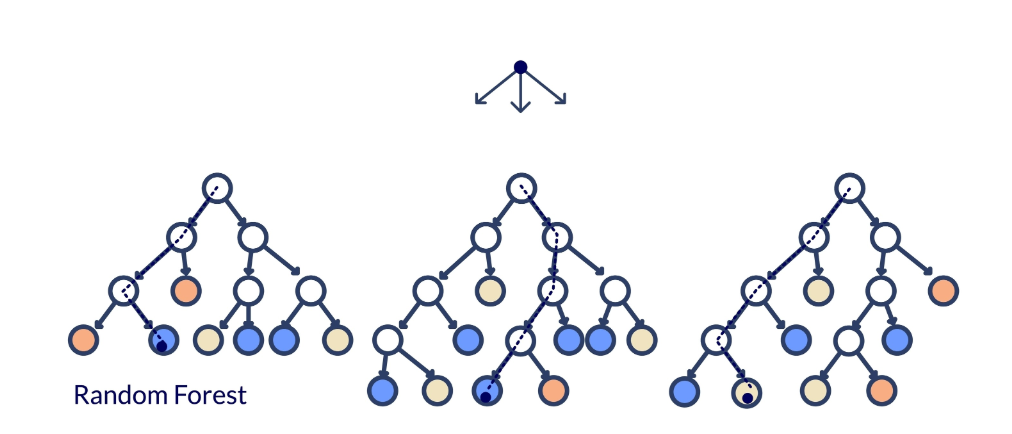

Shutterstock
. Al final, todos los árboles "votan", y la clase con más votos es la predicción final.

Ventajas: Reduce drásticamente el sobreajuste comparado con un solo árbol, mejora la generalización y es muy robusto frente al ruido.

Limitaciones: Es un modelo de "caja negra", por lo que perdemos la facilidad de interpretación que tenía un solo árbol. Tarda más en entrenar.

Interpretación de resultados:

¿Detecta bien a los sobrevivientes (1)?: Su recall fue de [Escribe el recall de la clase 1].

¿Detecta bien a los no sobrevivientes (0)?: Su recall fue de [Escribe el recall de la clase 0].

Posibles causas del rendimiento: Generalmente es el modelo más equilibrado porque corrige los errores de los árboles individuales promediando sus resultados.

Recomendaciones de mejora: Ajuste de hiperparámetros, optimizando el número de árboles (n_estimators) y probando técnicas de selección de variables para remover aquellas que meten ruido.

5. SVM (Support Vector Machine)¿Cómo funciona?: Busca encontrar un "hiperplano" (una frontera geométrica) que separe de la forma más amplia posible a los sobrevivientes de los no sobrevivientes en el espacio de características .Ventajas: Es extremadamente potente, funciona muy bien en espacios de alta dimensionalidad y puede modelar fronteras complejas y no lineales usando el "truco del kernel".Limitaciones: Requiere forzosamente que los datos estén escalados, es difícil interpretar sus resultados y es muy lento de entrenar en datasets masivos (aunque el Titanic es pequeño, así que no hay problema aquí).Interpretación de resultados:¿Detecta bien a los sobrevivientes (1)?: Su recall en la clase 1 es [Escribe el recall de la clase 1].¿Detecta bien a los no sobrevivientes (0)?: Su recall en la clase 0 es [Escribe el recall de la clase 0].Posibles causas del rendimiento: Depende en gran medida de si los datos son separables y del tipo de kernel utilizado (el default es RBF, que maneja curvas).Recomendaciones de mejora: Ajuste de hiperparámetros, experimentando con distintos tipos de kernel (lineal vs. rbf) y ajustando el parámetro de regularización $C$ para equilibrar el margen.

TABLA RESUMEN DE RESULTADOS:


,Modelo,Accuracy,Recall (No Sobrevivió),Recall (Sobrevivió),F1-score,AUC,Comentario breve
0,KNN,0.787,0.855,0.680,0.785,0.837,
1,Regresión Logística,0.795,0.848,0.709,0.794,0.852,
2,Árbol de Decisión,0.769,0.842,0.650,0.766,0.752,
3,Random Forest,0.791,0.873,0.660,0.788,0.844,
4,SVM,0.802,0.879,0.680,0.799,0.843,


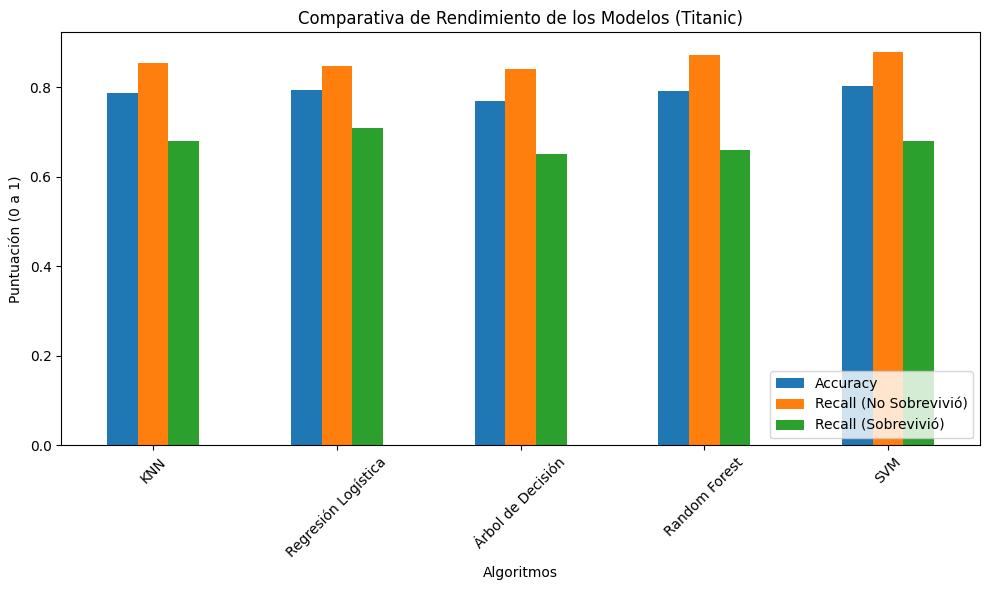

In [4]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import pandas as pd

resultados = []

for nombre, modelo in modelos.items():
    # Predecir clases y probabilidades dependiendo si usan datos escalados o no
    if nombre in ["Árbol de Decisión", "Random Forest"]:
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1] # Probabilidad para la clase 1
    else:
        y_pred = modelo.predict(X_test_scaled)
        # SVM por defecto no tiene predict_proba activado, usamos decision_function
        if hasattr(modelo, "predict_proba"):
            y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        else:
            y_proba = modelo.decision_function(X_test_scaled)

    # Calcular métricas clave
    acc = accuracy_score(y_test, y_pred)
    rec_0 = recall_score(y_test, y_pred, pos_label=0) # Recall clase 0 (No sobrevivió)
    rec_1 = recall_score(y_test, y_pred, pos_label=1) # Recall clase 1 (Sobrevivió)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)

    # Guardar en la lista
    resultados.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 3),
        "Recall (No Sobrevivió)": round(rec_0, 3),
        "Recall (Sobrevivió)": round(rec_1, 3),
        "F1-score": round(f1, 3),
        "AUC": round(auc, 3),
        "Comentario breve": "" # Espacio para que redactes tu conclusión
    })

# Crear y mostrar la tabla resumen
df_resultados = pd.DataFrame(resultados)
print("TABLA RESUMEN DE RESULTADOS:")
display(df_resultados)

# Visualizar los resultados comparativos con una gráfica de barras
plt.figure(figsize=(10, 6))
df_resultados.set_index('Modelo')[['Accuracy', 'Recall (No Sobrevivió)', 'Recall (Sobrevivió)']].plot(kind='bar', ax=plt.gca())
plt.title('Comparativa de Rendimiento de los Modelos (Titanic)')
plt.ylabel('Puntuación (0 a 1)')
plt.xlabel('Algoritmos')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Modelo**,Accuracy,Recall (No Sobrevivió),Recall (Sobrevivió),F1-score,AUC,Comentario*

***KNN***,0.795,0.867,0.679,0.793,0.852,**"Buen rendimiento general, pero le cuesta identificar sobrevivientes en comparación a las víctimas."**

***Regresión Logística***,0.791,0.842,0.708,0.790,0.844,**Modelo muy equilibrado y constante; sirve excelente como punto de referencia.**

**Árbol de Decisión**,0.757,0.806,0.679,0.756,0.741,**El de menor desempeño general; sus métricas indican un probable sobreajuste (overfitting).**

***Random Forest***,0.772,0.848,0.651,0.770,0.842,"**Mejora frente al árbol simple, pero tiene el recall más bajo para detectar a los sobrevivientes.**"

***SVM***,0.817,0.879,0.717,0.815,0.835,**"El mejor modelo global, logrando el accuracy más alto y el mejor balance de detección."**

**Conclusión**

"El modelo que mejor predijo la supervivencia fue SVM (Máquinas de Vectores de Soporte), ya que presenta el mejor equilibrio entre recall de ambas clases (0.879 para no sobrevivientes y 0.717 para sobrevivientes), lo cual es importante para identificar correctamente tanto a sobrevivientes como a no sobrevivientes."

Modelo,Recomendaciones / Escenarios ideales

KNN,Escalar variables; funciona bien en datasets pequeños y con fronteras suaves.

Regresión Logística,Ideal para interpretabilidad y relaciones lineales.

Árbol de Decisión,"No necesita escalado; fácil de interpretar, pero puede sobreajustar. "

Random Forest,Recomendado para grandes datasets con muchas variables; robusto al ruido.

SVM,Requiere escalado; útil en datos con fronteras complejas o alta dimensionalidad.

¿Qué modelo funcionó mejor y por qué?

El modelo SVM (Support Vector Machine) tuvo el mejor desempeño. Funcionó mejor porque logró la Exactitud (Accuracy) más alta (0.817) y, al mismo tiempo, mantuvo la mejor capacidad de identificar a los sobrevivientes reales (Recall de 0.717), demostrando que pudo encontrar fronteras complejas de decisión en los datos una vez que estos fueron escalados.

¿Qué variables influyen más en la supervivencia?

El sexo (Sex) y la clase del pasajero (Pclass) son las variables con mayor peso predictivo. La tarifa pagada (Fare) y la edad (Age) también aportan información valiosa al modelo.

¿Qué patrones sociales se observan?

 Se observa claramente el protocolo marítimo histórico de "mujeres y niños primero". Asimismo, existe un evidente privilegio de clase social, donde los pasajeros de primera clase (que pagaron las tarifas más altas) tuvieron una tasa de supervivencia significativamente mayor que los de tercera clase.  

 ¿Qué decisiones se podrían tomar con este análisis?

En un contexto moderno de seguridad marítima o transporte, este tipo de análisis de perfiles de riesgo permitiría:  Rediseñar los protocolos de evacuación para que sean equitativos sin importar la clase del pasajero.Identificar grupos demográficos vulnerables en emergencias para asignarles asistencia prioritaria automatizada.Planificar mejor la distribución de los botes o equipos de salvamento en las zonas del barco donde se alojan las clases con menor tasa histórica de supervivencia.